# Inventory-Biased Mean-Reversion Strategy (Peak)

This notebook connects to Coinbase for live price feeds and TrueMarkets for live execution.

In [1]:
import sys
import os
import asyncio
import time
from collections import deque
from pathlib import Path

# Ensure we can import the project libs
ROOT_DIR = Path(os.getcwd()).parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import aiohttp
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from dotenv import load_dotenv

from lib.execution import ExecutionClient
from lib.coinbase_feed import CoinbaseBookA

load_dotenv(ROOT_DIR / "keys" / ".env")

TM_REST_URL = os.getenv("BASE_REST_URL", "https://api.truemarkets.co")
TM_KEY_FILE = str(ROOT_DIR / "keys" / "truemarkets-api-key-edd1691b.json")
CB_WS_URL = os.getenv("COINBASE_WS_URL", "wss://ws-feed.exchange.coinbase.com")
CB_PRODUCT_ID = "BTC-USD"

In [2]:
import websockets
import json


class TrueMarketsBook:
    """
    Native TrueMarkets L2 order book via the DEPTH WebSocket channel.
    Endpoint discovered from the trading UI: wss://api.truex.co/api/v1
    No auth required — uses SUBSCRIBE_NO_AUTH.
    """

    _WS_URL = "wss://api.truex.co/api/v1"
    _HEADERS = {
        "Origin": "https://truemarkets.co",
        "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36",
        "Accept-Language": "en-US,en;q=0.9",
    }

    def __init__(self, symbol="BTC-PYUSD"):
        self.symbol = symbol
        self._bids: dict = {}   # price_float -> qty_float
        self._asks: dict = {}
        self._seqnum: int = 0
        self._ts: float = 0.0
        self._ready: bool = False

    @property
    def best_bid(self):
        return max(self._bids) if self._bids else None

    @property
    def best_ask(self):
        return min(self._asks) if self._asks else None

    @property
    def best_bid_size(self):
        b = self.best_bid
        return self._bids[b] if b is not None else None

    @property
    def best_ask_size(self):
        a = self.best_ask
        return self._asks[a] if a is not None else None

    @property
    def mid(self):
        b, a = self.best_bid, self.best_ask
        return (b + a) / 2.0 if (b is not None and a is not None) else None

    @property
    def is_ready(self):
        return self._ready

    def age(self):
        return float("inf") if self._ts == 0.0 else time.time() - self._ts

    def _handle_snapshot(self, data):
        self._bids = {float(b["price"]): float(b["qty"]) for b in data.get("bids", []) if float(b["qty"]) > 0}
        self._asks = {float(a["price"]): float(a["qty"]) for a in data.get("asks", []) if float(a["qty"]) > 0}
        self._ready = True
        self._ts = time.time()

    def _handle_update(self, data):
        for b in data.get("bids", []):
            price, qty = float(b["price"]), float(b["qty"])
            if qty == 0:
                self._bids.pop(price, None)
            else:
                self._bids[price] = qty
        for a in data.get("asks", []):
            price, qty = float(a["price"]), float(a["qty"])
            if qty == 0:
                self._asks.pop(price, None)
            else:
                self._asks[price] = qty
        self._ts = time.time()

    async def run(self):
        backoff = 1
        while True:
            try:
                async with websockets.connect(self._WS_URL, additional_headers=self._HEADERS) as ws:
                    backoff = 1
                    self._ready = False
                    sub = {
                        "type": "SUBSCRIBE_NO_AUTH",
                        "item_names": [self.symbol],
                        "channels": ["DEPTH"],
                        "timestamp": str(int(time.time())),
                    }
                    await ws.send(json.dumps(sub))
                    logging.info(f"TrueMarketsBook: subscribed to DEPTH for {self.symbol}")
                    async for raw in ws:
                        try:
                            msg = json.loads(raw)
                        except Exception:
                            continue
                        self._seqnum = msg.get("seqnum", self._seqnum)
                        update_type = msg.get("update")
                        data = msg.get("data", {})
                        if update_type == "SNAPSHOT":
                            self._handle_snapshot(data)
                        elif update_type == "UPDATE":
                            self._handle_update(data)
            except websockets.ConnectionClosed as e:
                logging.warning(f"TrueMarketsBook: closed (code={e.code}), reconnecting in {backoff}s")
            except Exception as e:
                logging.error(f"TrueMarketsBook: error {e}, reconnecting in {backoff}s")
            self._ready = False
            await asyncio.sleep(backoff)
            backoff = min(backoff * 2, 30)


### Strategy Parameters

In [3]:
TRADE_SIZE_BTC   = 0.0001   # size of each resting order
MAX_POSITION_BTC = 0.0005   # max net long or short before suppressing that side
DAILY_LOSS_LIMIT = 50.0     # stop and flatten if session PnL drops below -$DAILY_LOSS_LIMIT

BASE_ASSET  = "BTC"
QUOTE_ASSET = "USDC"

# How often to cancel and re-quote (seconds)
EVAL_INTERVAL = 3

# TrueMarkets native book symbol (DEPTH channel)
TM_BOOK_SYMBOL = "BTC-PYUSD"

# Minimum BTC size at the top of a side to quote against it
MM_SIZE_THRESHOLD = 0.001

# How far inside the best bid/ask to quote, as a fraction of the current spread.
# 0.05 means each side moves 5% of the spread toward mid:
#   new_bid = best_bid + 0.05 * spread
#   new_ask = best_ask - 0.05 * spread
SPREAD_IMPROVE_PCT = 0.05

# TrueMarkets price tick and decimal precision
TICK_SIZE      = 0.1
PRICE_DECIMALS = 1


### Helpers and Plotting

In [4]:
time_series = []
pnl_series = []
volume_series = []
inventory_series = []

def format_size(size: float) -> str:
    return f"{size:.8f}".rstrip("0").rstrip(".")

def update_plot():
    clear_output(wait=True)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    
    ax1.plot(time_series, pnl_series, label="Total PnL ($)", color="green")
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.axhline(-DAILY_LOSS_LIMIT, color='red', linestyle='--', label="Loss Limit")
    ax1.set_ylabel("PnL ($)")
    ax1.set_title("Portfolio Performance")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(time_series, volume_series, label="Volume ($)", color="blue")
    ax2.set_ylabel("Cum. Volume ($)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    ax3.plot(time_series, inventory_series, label="Inventory (BTC)", color="orange")
    ax3.set_ylabel("Inventory (BTC)")
    ax3.set_xlabel("Time (s)")
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    display(fig)
    plt.close(fig)


### Logging Setup

In [5]:
import logging
import time

logger = logging.getLogger()
logger.setLevel(logging.INFO)
# Remove old handlers if any
for handler in logger.handlers[:]:
    logger.removeHandler(handler)
fh = logging.FileHandler('peak.log', mode='w')
fh.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
logger.addHandler(fh)

def log_and_print(msg):
    print(msg)
    logging.info(msg)


### Main Strategy Loop

In [ ]:
import math
import asyncio
import time
import aiohttp
import logging

# Ensure these are defined in your environment
# BASE_ASSET = "BTC"
# QUOTE_ASSET = "USDC"
# PRICE_DECIMALS = 2
# DAILY_LOSS_LIMIT = 50.0  
# TM_KEY_FILE = ...
# TM_REST_URL = ...

def log_and_print(msg):
    print(msg)
    logging.info(msg)

async def get_detailed_balances(bot, session):
    data = await bot._get(session, "/v1/conductor/balances")
    btc_total = btc_avail = usd_total = usd_avail = 0.0
    if data is None or "data" not in data:
        return None, None, None, None
    for b in data.get("data", []):
        sym   = b.get("symbol", "")
        avail = float(b.get("available", 0))
        held  = float(b.get("held", 0))
        if sym == BASE_ASSET:
            btc_avail += avail
            btc_total += avail + held
        elif sym in (QUOTE_ASSET, "PYUSD"):
            usd_avail += avail
            usd_total += avail + held
    return btc_total, usd_total, btc_avail, usd_avail

async def cancel_quietly(bot, session, order_id):
    """Cancel an order, swallowing errors if it was already filled or not found."""
    if not order_id:
        return
    try:
        await bot.cancel_order(session, order_id)
    except Exception:
        pass

def format_size(size):
    """Helper to format BTC sizes."""
    return f"{size:.4f}"

# --- Ping Pong Configuration ---
TRADE_SIZE_BTC = 0.005
ASK_PRICE = "70000"      # Using 0.01 in case the exchange rejects exactly 0.00
BID_PRICE = "50000"
OFFSET = 200

async def run_strategy():
    global time_series, pnl_series, volume_series, inventory_series

    # Re-initialize plot series
    time_series = []
    pnl_series  = []
    volume_series = []
    inventory_series = []

    total_volume_usdc = 0.0
    
    bot     = ExecutionClient(key_file=TM_KEY_FILE, base_url=TM_REST_URL)
    book_a  = CoinbaseBookA(ws_url=CB_WS_URL, product_id=CB_PRODUCT_ID)  # Required for mark_price & PnL
    tm_book = TrueMarketsBook(symbol=TM_BOOK_SYMBOL)

    feed_task_cb = asyncio.create_task(book_a.run())
    feed_task_tm = asyncio.create_task(tm_book.run())

    start_time = time.time()

    try:
        async with aiohttp.ClientSession() as session:
            await bot.authenticate(session)
            log_and_print("Authenticated with TrueMarkets.")

            log_and_print("Cancelling any existing orders to start clean...")
            await bot.cancel_all(session)

            balances_res = await get_detailed_balances(bot, session)
            if balances_res[0] is None:
                raise Exception("Failed to fetch initial balances.")
            
            btc_total, usd_total, btc_avail, usd_avail = balances_res
            initial_usd_balance = usd_total
            # NOTE: BTC is NOT zeroed against a baseline. inventory_btc below always
            # equals your real, current BTC balance — if this run starts while you're
            # already holding BTC, it shows up immediately instead of reading as "0".
            previous_btc_balance = btc_total

            # Baseline portfolio value (set once we have a mark price) so PnL still
            # measures what THIS session made/lost, even though inventory itself
            # is now an absolute balance rather than a delta from a reset baseline.
            initial_portfolio_value = None
            
            log_and_print(f"Initial balances: {btc_total:.8f} BTC | {usd_total:.2f} USDC/PYUSD")
            log_and_print("Waiting for mark price...")

            # State Machine: "bidding" or "asking"
            current_state = "asking"
            active_order_id = None

            while True:
                await asyncio.sleep(2)
                now = time.time()

                # ── Balances & Volume ────────────────────────────────────────────────
                balances_res = await get_detailed_balances(bot, session)
                if balances_res[0] is None:
                    log_and_print("Balance fetch failed, skipping cycle.")
                    continue
                
                btc_total, usd_total, btc_avail, usd_avail = balances_res
                
                # Real, current BTC balance — no baseline subtraction.
                inventory_btc = btc_total
                diff_btc      = btc_total - previous_btc_balance
                
                mark_price = book_a.mid or tm_book.mid
                if abs(diff_btc) > 1e-8 and mark_price:
                    total_volume_usdc += abs(diff_btc) * mark_price
                previous_btc_balance = btc_total

                if mark_price is None:
                    log_and_print("No mark price yet, waiting...")
                    continue

                if initial_portfolio_value is None:
                    initial_portfolio_value = initial_usd_balance + inventory_btc * mark_price

                # ── PnL & Plotting ───────────────────────────────────────────────────
                current_portfolio_value = usd_total + inventory_btc * mark_price
                total_pnl = current_portfolio_value - initial_portfolio_value
                elapsed   = now - start_time

                time_series.append(elapsed)
                pnl_series.append(total_pnl)
                volume_series.append(total_volume_usdc)
                inventory_series.append(inventory_btc)
                
                # Assuming update_plot() is defined globally in your environment
                update_plot()

                # ── Loss Limit ───────────────────────────────────────────────────────
                if total_pnl < -DAILY_LOSS_LIMIT:
                    log_and_print(f"LOSS LIMIT HIT (${total_pnl:.2f}). Flattening and stopping.")
                    await cancel_quietly(bot, session, active_order_id)
                    break

                print(inventory_btc, TRADE_SIZE_BTC * 0.99, TRADE_SIZE_BTC * 0.10)

                # ── State Transition Logic ───────────────────────────────────────────
                if current_state == "bidding" and inventory_btc >= TRADE_SIZE_BTC * 0.99:
                    log_and_print(f">>> BID FILLED! {inventory_btc} Switching to ASK.")
                    current_state = "asking"
                    active_order_id = None
                
                elif current_state == "asking" and inventory_btc < TRADE_SIZE_BTC * 0.10:
                    log_and_print(f">>> ASK FILLED! {inventory_btc} Switching back to BID.")
                    current_state = "bidding"
                    active_order_id = None

                else:
                    log_and_print(f">>> NO FLIP! {inventory_btc} STAYING ON {current_state}")
                    log_and_print(f">>> {inventory_btc} || {TRADE_SIZE_BTC}")

                # ── Order Placement ──────────────────────────────────────────────────
                if active_order_id is None:
                    MID_PRICE = round(mark_price, 0)
                    if current_state == "bidding":
                        order = await bot.place_order(
                            session, BASE_ASSET, QUOTE_ASSET, "buy",
                            format_size(TRADE_SIZE_BTC), "base", "limit",
                            price=f"{MID_PRICE + OFFSET}"
                        )

                        if order and order.get("order_id"):
                            active_order_id = order["order_id"]
                            log_and_print(f"PLACED BID: {format_size(TRADE_SIZE_BTC)} BTC @ ${MID_PRICE + OFFSET}")
                        else:
                            log_and_print("FAILED TO PLACE BID")
                            
                    elif current_state == "asking":
                        if btc_avail >= TRADE_SIZE_BTC:
                            order = await bot.place_order(
                                session, BASE_ASSET, QUOTE_ASSET, "sell",
                                format_size(TRADE_SIZE_BTC), "base", "limit",
                                price=f"{MID_PRICE - OFFSET}"
                            )
                            if order and order.get("order_id"):
                                active_order_id = order["order_id"]
                                log_and_print(f"PLACED ASK: {format_size(TRADE_SIZE_BTC)} BTC @ ${MID_PRICE - OFFSET}")
                            else:
                                log_and_print("FAILED TO PLACE ASK")
                        else:
                            log_and_print("WAITING: Insufficient available BTC to place ask.")

                # ── Logging ──────────────────────────────────────────────────────────
                log_and_print(
                    f"t={elapsed:.0f}s | mark={mark_price:.1f} | "
                    f"pos={inventory_btc:+.4f} BTC | PnL=${total_pnl:.2f} | vol=${total_volume_usdc:.2f}"
                )
                log_and_print(f"State: {current_state.upper()} | Avail USD: ${usd_avail:.2f}")
                log_and_print("-" * 55)

    except asyncio.CancelledError:
        pass
    finally:
        feed_task_cb.cancel()
        feed_task_tm.cancel()
        log_and_print("Shutting down Ping-Pong strategy.")

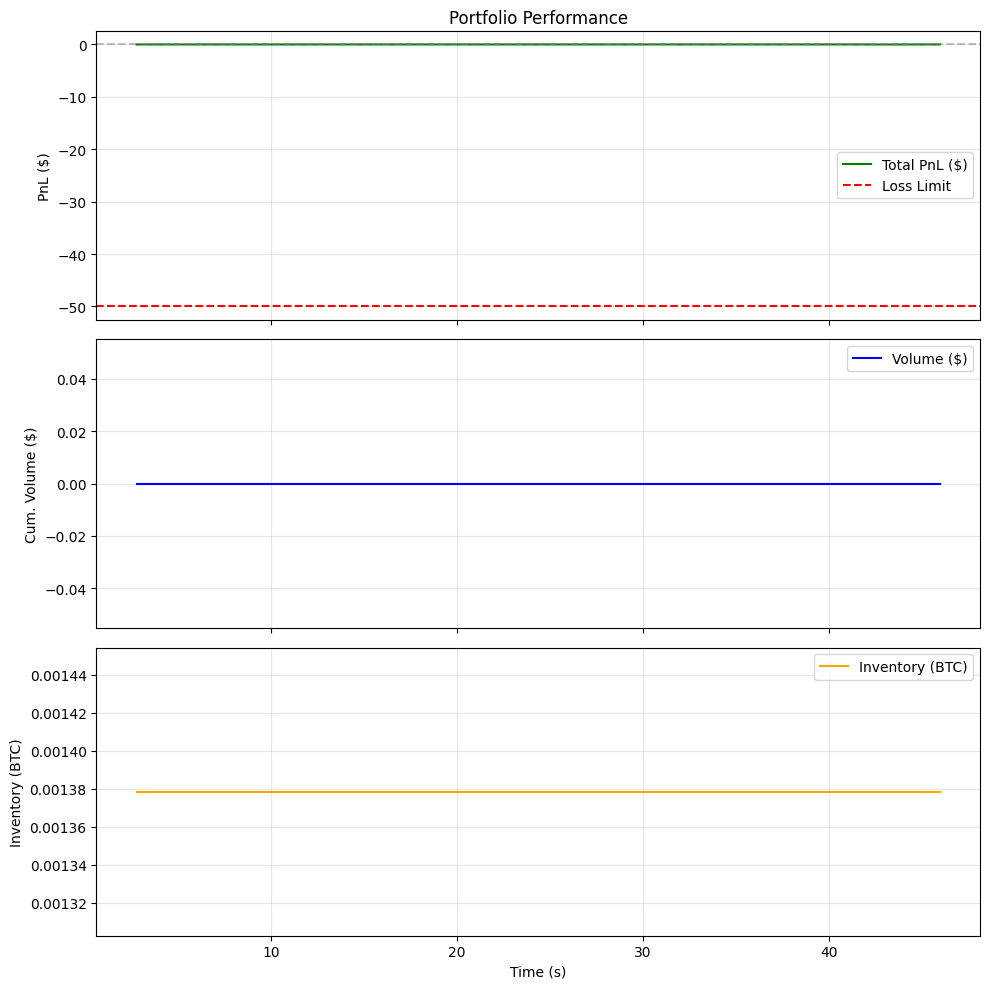

0.00137842 0.00891 0.0009
>>> NO FLIP! 0.00137842 STAYING ON asking
>>> 0.00137842 || 0.009
WAITING: Insufficient available BTC to place ask.
t=46s | mark=77582.4 | pos=+0.0014 BTC | PnL=$0.00 | vol=$0.00
State: ASKING | Avail USD: $650.17
-------------------------------------------------------
Shutting down Ping-Pong strategy.


In [7]:
# To stop the loop, interrupt the kernel (Stop button)
await run_strategy()

### MM Presence Monitor

Connects to the native TrueMarkets DEPTH WebSocket (`wss://api.truex.co/api/v1`) and tracks how often a market maker with ≥ `MM_SIZE_THRESHOLD` BTC is sitting at both best bid and best ask. Run this standalone — don't run it in the same kernel session as `run_strategy`.

In [ ]:
async def monitor_mm_presence(duration_seconds=120):
    """
    Watch the native TrueMarkets DEPTH book and record how often a large MM
    (>= MM_SIZE_THRESHOLD BTC) is sitting at both best bid and best ask.
    """
    presence_log = []  # (elapsed_s, mm_present, bid_size, ask_size)

    tm_book = TrueMarketsBook(symbol=TM_BOOK_SYMBOL)
    feed_task = asyncio.create_task(tm_book.run())

    start = time.time()
    print(f"Monitoring TrueMarkets {TM_BOOK_SYMBOL} DEPTH for {duration_seconds}s  "
          f"(threshold: {MM_SIZE_THRESHOLD} BTC) — interrupt kernel to stop early")

    try:
        while time.time() - start < duration_seconds:
            await asyncio.sleep(0.5)
            if not tm_book.is_ready:
                continue

            bid_sz = tm_book.best_bid_size or 0.0
            ask_sz = tm_book.best_ask_size or 0.0
            mm_present = bid_sz >= MM_SIZE_THRESHOLD and ask_sz >= MM_SIZE_THRESHOLD
            presence_log.append((time.time() - start, mm_present, bid_sz, ask_sz))

            if len(presence_log) % 20 == 0:
                pct = 100 * sum(1 for _, p, _, _ in presence_log if p) / len(presence_log)
                bb, ba = tm_book.best_bid, tm_book.best_ask
                print(
                    f"\r  t={presence_log[-1][0]:.0f}s  "
                    f"bid_sz={bid_sz:.5f}  ask_sz={ask_sz:.5f}  "
                    f"MM={'YES' if mm_present else 'NO '}  "
                    f"uptime={pct:.1f}%  "
                    f"BBO={bb:.1f}/{ba:.1f}  seq={tm_book._seqnum}",
                    end=""
                )
    except asyncio.CancelledError:
        pass
    finally:
        feed_task.cancel()

    print()

    if not presence_log:
        print("No data collected.")
        return []

    times   = [r[0] for r in presence_log]
    present = [1 if r[1] else 0 for r in presence_log]
    bid_szs = [r[2] for r in presence_log]
    ask_szs = [r[3] for r in presence_log]

    pct_present = 100 * sum(present) / len(present)
    avg_bid = sum(bid_szs) / len(bid_szs)
    avg_ask = sum(ask_szs) / len(ask_szs)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

    ax1.fill_between(times, present, step='post', alpha=0.45, color='green', label='MM present')
    ax1.step(times, present, where='post', color='green', linewidth=1)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Absent', 'Present'])
    ax1.set_title(
        f'Large MM presence — TrueMarkets {TM_BOOK_SYMBOL} DEPTH  '
        f'(≥{MM_SIZE_THRESHOLD} BTC both sides)   uptime {pct_present:.1f}%'
    )
    ax1.set_ylabel('MM Status')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    ax2.plot(times, bid_szs, color='steelblue', alpha=0.75, linewidth=0.8, label=f'Best bid size (avg {avg_bid:.5f})')
    ax2.plot(times, ask_szs, color='tomato',    alpha=0.75, linewidth=0.8, label=f'Best ask size (avg {avg_ask:.5f})')
    ax2.axhline(MM_SIZE_THRESHOLD, color='black', linestyle='--', linewidth=1,
                label=f'Threshold ({MM_SIZE_THRESHOLD} BTC)')
    ax2.set_ylabel('Size (BTC)')
    ax2.set_xlabel('Elapsed time (s)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*52}")
    print(f"  Symbol    : {TM_BOOK_SYMBOL}")
    print(f"  Samples   : {len(presence_log):,}  (~{duration_seconds}s at 2 Hz)")
    print(f"  MM uptime : {pct_present:.1f}%")
    print(f"  Avg bid sz: {avg_bid:.6f} BTC")
    print(f"  Avg ask sz: {avg_ask:.6f} BTC")
    print(f"{'='*52}")
    return presence_log


Monitoring TrueMarkets BTC-PYUSD DEPTH for 120s  (threshold: 0.001 BTC) — interrupt kernel to stop early
  t=120s  bid_sz=0.00119  ask_sz=0.00090  MM=NO   uptime=0.0%  BBO=77439.6/77649.0  seq=116903


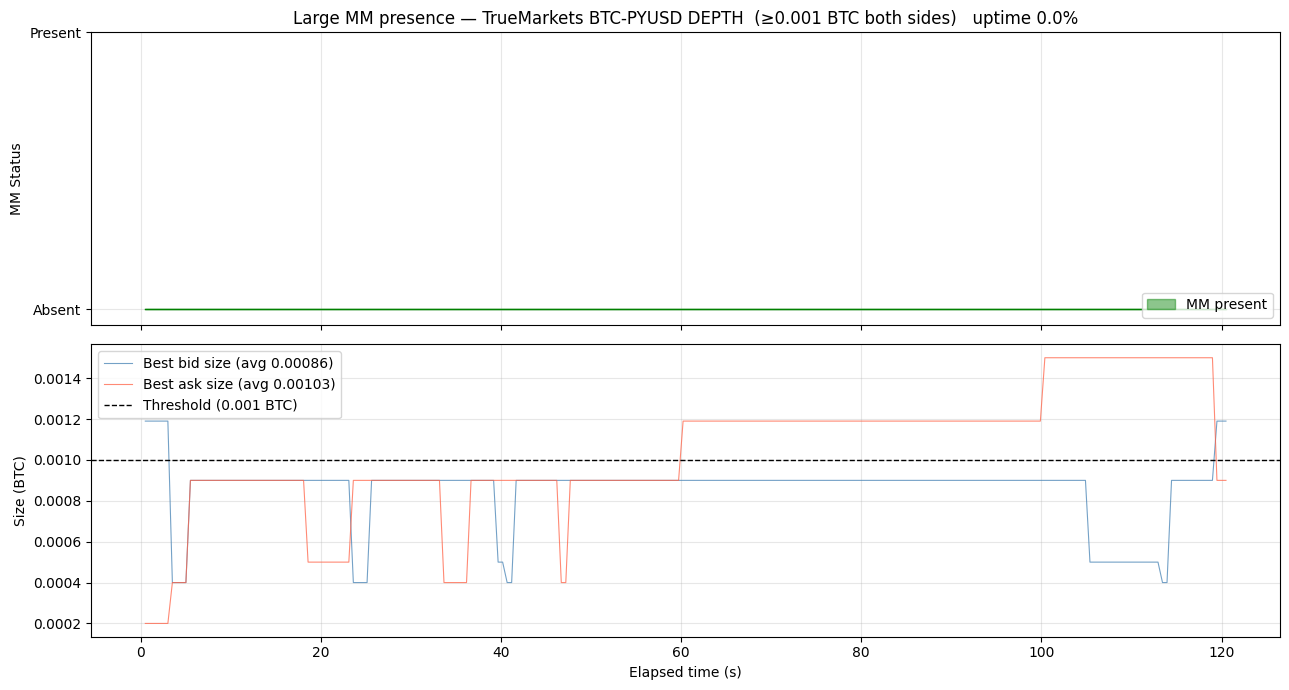


  Symbol    : BTC-PYUSD
  Samples   : 240  (~120s at 2 Hz)
  MM uptime : 0.0%
  Avg bid sz: 0.000856 BTC
  Avg ask sz: 0.001032 BTC


In [ ]:
# Adjust duration_seconds to taste; 120 = 2 minutes of observation
presence_log = await monitor_mm_presence(duration_seconds=120)

### Order History and Volume

In [ ]:
from datetime import datetime
import matplotlib.pyplot as plt
import urllib.parse

async def plot_volume_history():
    bot = ExecutionClient(key_file=TM_KEY_FILE, base_url=TM_REST_URL)
    async with aiohttp.ClientSession() as session:
        await bot.authenticate(session)
        cursor = None
        trades = []
        
        print("Fetching order history...")
        while True:
            path = "/v1/conductor/orders?status=complete"
            if cursor:
                path += f"&cursor={urllib.parse.quote(cursor)}"
            
            data = await bot._get(session, path)
            if not data:
                break
                
            orders = data.get("data", [])
            if not orders:
                break
                
            for o in orders:
                exec_qty = float(o.get("executed_qty", 0))
                exec_vwap = float(o.get("executed_vwap", 0))
                fee = float(o.get("fee", 0))
                usd_vol = exec_qty * exec_vwap
                
                created_at = o.get("created_at")
                if created_at and usd_vol > 0:
                    try:
                        time_str = created_at.split('.')[0] if '.' in created_at else created_at.rstrip('Z')
                        time_str = time_str.replace('Z', '')
                        ts = datetime.strptime(time_str, "%Y-%m-%dT%H:%M:%S").timestamp()
                        trades.append((ts, usd_vol, fee))
                    except Exception as e:
                        print("Error parsing timestamp:", e)
                        
            pagination = data.get("pagination", {})
            cursor = pagination.get("next_cursor") or data.get("next_cursor")
            if not cursor:
                break
                
        if not trades:
            print("No executed trades found to plot.")
            return
            
        # Sort trades by time
        trades.sort(key=lambda x: x[0])
        
        times = []
        cum_vols = []
        cum_fees = []
        current_vol = 0.0
        current_fee = 0.0
        for ts, vol, fee in trades:
            current_vol += vol
            current_fee += fee
            times.append(ts)
            cum_vols.append(current_vol)
            cum_fees.append(current_fee)
            
        # Normalize time to "Minutes since first trade" for better readability
        first_ts = times[0]
        times = [(t - first_ts) / 60.0 for t in times]
            
        print(f"Total Traded Volume: ${current_vol:.2f}")
        print(f"Total Fees Paid: ${current_fee:.2f}")
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
        
        ax1.plot(times, cum_vols, color='blue', linewidth=2)
        ax1.fill_between(times, cum_vols, color='blue', alpha=0.1)
        ax1.set_title("Cumulative Volume Traded")
        ax1.set_ylabel("Cumulative Volume ($)")
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(times, cum_fees, color='red', linewidth=2)
        ax2.fill_between(times, cum_fees, color='red', alpha=0.1)
        ax2.set_title("Cumulative Fees Paid")
        ax2.set_xlabel("Minutes Since First Trade")
        ax2.set_ylabel("Cumulative Fees ($)")
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

await plot_volume_history()


Fetching order history...


CancelledError: 

### Expected BTC Balance Reconciliation

In [ ]:
async def calculate_expected_btc_balance():
    bot = ExecutionClient(key_file=TM_KEY_FILE, base_url=TM_REST_URL)
    async with aiohttp.ClientSession() as session:
        await bot.authenticate(session)

        # --- Current live balance ---
        balance_data = await bot._get(session, "/v1/conductor/balances")
        current_btc = 0.0
        if balance_data:
            for b in balance_data.get("data", []):
                if b.get("symbol") == BASE_ASSET:
                    current_btc += float(b.get("available", 0) or 0) + float(b.get("held", 0) or 0)

        # --- All completed orders ---
        print("Fetching completed orders...")
        cursor = None
        btc_bought = btc_sold = 0.0
        buy_count = sell_count = 0
        while True:
            path = "/v1/conductor/orders?status=complete"
            if cursor:
                path += f"&cursor={urllib.parse.quote(cursor)}"
            data = await bot._get(session, path)
            if not data:
                break
            orders = data.get("data", [])
            if not orders:
                break
            for o in orders:
                exec_qty = float(o.get("executed_qty", 0) or 0)
                side = o.get("side", "")
                if side == "buy" and exec_qty > 0:
                    btc_bought += exec_qty
                    buy_count += 1
                elif side == "sell" and exec_qty > 0:
                    btc_sold += exec_qty
                    sell_count += 1
            cursor = (data.get("pagination") or {}).get("next_cursor")
            if not cursor:
                break

        # --- All completed BTC transfers (outgoing) ---
        print("Fetching BTC transfers...")
        cursor = None
        btc_transferred = 0.0
        transfer_count = 0
        while True:
            path = "/v1/conductor/transfers?status=complete"
            if cursor:
                path += f"&cursor={urllib.parse.quote(cursor)}"
            data = await bot._get(session, path)
            if not data:
                break
            transfers = data.get("data", [])
            if not transfers:
                break
            for t in transfers:
                if t.get("asset_symbol") == BASE_ASSET:
                    btc_transferred += float(t.get("qty", 0) or 0)
                    transfer_count += 1
            cursor = (data.get("pagination") or {}).get("next_cursor")
            if not cursor:
                break

        net_from_trading = btc_bought - btc_sold
        net_activity     = net_from_trading - btc_transferred

        print()
        print("=" * 55)
        print("      EXPECTED BTC BALANCE RECONCILIATION")
        print("=" * 55)
        print(f"  Buy  Orders ({buy_count:>4})      : +{btc_bought:.8f} BTC")
        print(f"  Sell Orders ({sell_count:>4})      : -{btc_sold:.8f} BTC")
        print(f"  Net from Trading         :  {net_from_trading:+.8f} BTC")
        print(f"  BTC Transfers Out ({transfer_count:>3}) : -{btc_transferred:.8f} BTC")
        print("-" * 55)
        print(f"  Expected Net Activity    :  {net_activity:+.8f} BTC")
        print("=" * 55)
        print(f"  Current Live Balance     :  {current_btc:.8f} BTC")
        print("=" * 55)

await calculate_expected_btc_balance()


Fetching completed orders...


CancelledError: 